# Plotting with Python

This script will plot the results of your manual analysis of the time fish spent in each section of the tank.  

This *notebook* has sections which are blocks of code that can be *executed* and sections which are text that describes the code and asks questions for your group to consider.  

## First
Read through the notebook as a group to get a general understanding of what this notebook is doing.  **Do not run any code!**

## Second
Carefully go through the notebook, running the cells of code and trying the challenge questions.  Work together on this and call over a helper if you have questions!

> To run a block of code, click in the box and hit 'shift + return'.

You should not need this link, but it is here in case we need it:
[Binder link to this notebook](https://mybinder.org/v2/gh/heattard/NU-Camp-2026/HEAD)

### The first thing we always need to do is import *packages* that we will use.  

- `import`: command to import the named package
- `as` gives shorthand for that package.  For example, instead of needing to write `pandas` every time we use pandas, we can just write `pd`   
- In python `#` is a comment.  That tells the computer to ignore whatever text comes after it.  Commenting your code is important because it helps others (including future you!) understand *why* you've odne something

In [7]:
import pandas as pd #pandas gives an helpful way to deal with two-dimensional data (columns and rows)
import numpy as np #this has more math options
import matplotlib.pyplot as plt #plotting.  Based on MATLAB

### Now we need to read in the data file.

## First upload your data
On the left, click the arrow that's pointed up to upload your csv file. Once you have uploaded it, you should see it listed on the left.

## Second, tell the computer what file to open
In the below cell, replace the words `'your file'` with the *name* of your file.  This tells the computer what file to open

> Challenge: What package are we using the read in teh data?

## Third, run the cell!
Run the cell below and look at the ouptut.  This cell block reads in your data and puts it into a variable called `df`

`df` stands for **dataframe** which is what pandas calls a table of data.

Now, whenever we want to use some of that data from our csv file, we just need to use the variable `df`

In [8]:
df = pd.read_csv('/content/01_20260804_NTT-Scoring.csv') # read in the data
df #print the data

,Group Number,Top Region Entry,Top Region Exit,Bottom Region Entry,Bottom Region Exit
0,1.0,1.50,2.33,-0.50,1.01
1,1.0,17.50,17.39,16.89,59.59
2,1.0,60.09,60.06,59.56,72.56
3,1.0,73.06,72.85,72.35,89.01
4,1.0,89.51,89.45,88.95,96.87
5,1.0,97.37,97.55,97.05,110.69
6,1.0,111.19,113.93,113.43,116.40
7,1.0,116.90,117.61,117.11,125.22
8,1.0,125.72,128.33,127.83,141.37
9,1.0,141.87,144.78,144.28,152.63


## Let's Explore the data a bit more...

If we only want information on one column we can type `df['ColumnName']`

Run the cell below to see how it only prints out information about when the fish *entered* the Top Region

> **Challenge 1**: Print out when the fish *exited* the Top Region

> **Challenge 2**: Print out when the fish entered *and* exited the region

In [9]:
df['Top Region Entry']

,Top Region Entry
0,1.50
1,17.50
2,60.09
3,73.06
4,89.51
5,97.37
6,111.19
7,116.90
8,125.72
9,141.87


### Find the elapsed time from each row

This block of code finds the total amount of time in each row by subtracting the start and end times for each row and putting it in a new column called `Top_time_delta` and `Bottom_time_delta`

> Challenge: In the cell below, add a new line that prints out the dataframe. Compare it to the dataframe you printed out originally -- whats different?

Notice how you have *updated* the variable `df`

In [10]:
df['Top_time_delta'] = df['Top Region Exit']-df['Top Region Entry']
df['Bottom_time_delta'] = df['Bottom Region Exit']-df['Bottom Region Entry']

,Group Number,Top Region Entry,Top Region Exit,Bottom Region Entry,Bottom Region Exit,Top_time_delta,Bottom_time_delta
0,1.0,1.50,2.33,-0.50,1.01,0.83,1.51
1,1.0,17.50,17.39,16.89,59.59,-0.11,42.70
2,1.0,60.09,60.06,59.56,72.56,-0.03,13.00
3,1.0,73.06,72.85,72.35,89.01,-0.21,16.66
4,1.0,89.51,89.45,88.95,96.87,-0.06,7.92
5,1.0,97.37,97.55,97.05,110.69,0.18,13.64
6,1.0,111.19,113.93,113.43,116.40,2.74,2.97
7,1.0,116.90,117.61,117.11,125.22,0.71,8.11
8,1.0,125.72,128.33,127.83,141.37,2.61,13.54
9,1.0,141.87,144.78,144.28,152.63,2.91,8.35


### Find the total number of minutes we have in the data

Get the maximum from the two exit rows, divide by 60 and then round UP every time to the nearest whole number

In [11]:
total_mins = np.ceil(df[['Top Region Exit','Bottom Region Exit']].max().max() / 60)
print(total_mins)

3.0


### Sum up the data in 30 second increments.

We want to konw how long the fish spent in each section for 30-second increments.  

For example, from 0-30s, how long was the fish in the Top region? Bottom Region?  We can then plot that to see where it spent the most time for each 30 second increment for as much data as we have (which we found out in the cell above).

The below code sums this up and plots the data.  Look through and run the code as it is to see how it outputs, then try some of the challenges below.
  

> Challenge 1: Where does the fish spend the most time? What does this mean about how it was feeling?

> Challenge 2: Instead of 30 second intervals, sum the data over 20 second intervals.  Compare this to the 30 second plot you already made.  Does it look different? Try some different intervals!

> Challenge 3: Change the line color

> Challenge 4: Whats the advantage of setting variables instead of just writing the value you want throughtout the code?

[  0.  30.  60.  90. 120. 150.]
[0.  0.5 1.  1.5 2.  2.5]
[0.5 1.  1.5 2.  2.5 3. ]
[ 0.72  0.   -0.3   3.63  5.52  1.24]
[13.11 30.03 30.27 26.37 24.48 27.44]


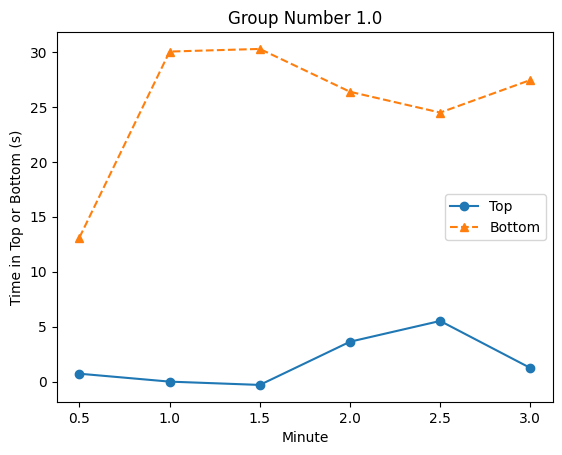

In [15]:
from matplotlib import lines
second_interval = 30

seconds = np.arange(0,total_mins*60,second_interval) #array of bins in seconds
minutes = np.arange(0,total_mins,second_interval/60) # make a list of times from 0 to total_mins; +1 b/c not inclusive
print(seconds)
print(minutes) #prints it out
bins = np.zeros(len(minutes)) #this will hold the data for each minute for the top

x_axis = minutes + (second_interval/60) #the x-axis labels will start at the second interval
print(x_axis)
marks = ['o','^']
lines = ['solid','dashed']

for i,u in enumerate(['Top','Bottom']): #loop through each fish.  u will be the fish ID, i will be a counter starting at 0
  ##############
  ##### This is all getting the data
  #####################

  for j,t in enumerate(seconds): #loop through each interval bin to get data for it
    #print(f'on {u} and {t}')
    bins[j] = bins[j] + np.round(df[(df[f'{u} Region Entry'] >= t) & (df[f'{u} Region Exit'] < t+second_interval)][f'{u}_time_delta'].sum(),2)

    for l in range(len(df)):
      if (df[f'{u} Region Entry'].iloc[l] < t + second_interval ) and (df[f'{u} Region Exit'].iloc[l] > t + second_interval): #it crosses the bin boundary

        if (t > df[f'{u} Region Entry'].iloc[l] ): #check if the starting time is ALSO between these times:
          bins[j] = np.round(bins[j] + ( (t+second_interval) - t),2)
          #print(f'new total: {bins[j]}')
        else:
          bins[j] = np.round(bins[j] + ( (t+second_interval) - df[f'{u} Region Entry'].iloc[l]),2)
          if df[f'{u} Region Exit'].iloc[l] > t+(second_interval*2):
            #print('in if')
            continue
          else:
            bins[j+1] = np.round(bins[j+1] + np.abs((t+second_interval) - df[f'{u} Region Exit'].iloc[l]),2)

  #######################
  ####This is the plotting
  ##### The code makes one plot but puts two lines on the plot, one for when the fish are in the top and one for them in the bottom
  ##################
  print(bins)
  plt.plot(x_axis,bins,marker=marks[i],linestyle=lines[i],label=u)
  #plt.xticks(x_axis,x_axis)#,rotation=45, ha='right')
  #axs[i].legend()
  #axs[i].tick_params(axis='x', labelbottom=True) #label x tick marks on each plot
  bins = np.zeros(len(minutes))

#########
###Now we are out of the loop and making the plot prettier
################
group = df['Group Number'].iloc[0]
plt.title(f'Group Number {group}')
plt.legend()
plt.xlabel("Minute") #label the x axis
plt.ylabel("Time in Top or Bottom (s)")

plt.savefig(f'Group{group}_every{second_interval}seconds.png')